Import libraries

In [10]:
import numpy as np
import pandas as pd
import tensorflow as tf
import matplotlib.pyplot as plt

Load data

In [8]:
df = pd.read_csv('data.csv')

labels = df['label'].values
features = df.drop('label', axis=1)

features = (features.values / 255.0)  # normalise pixel values to range 0 to 1

# divide data into training and testing samples. TensorFlow uses convention Z= XW+b instead of WX+b so transpose is not required

not_test_features = features[:40000]
not_test_labels = labels[:40000]

# We can also have a validation set to see how loss changes on unseen data during training. Most of the data will be used for training. 

training_features = features[:35000]
training_labels = labels[:35000]

validation_features = features[35000:]
validation_labels = labels[35000:]

testing_features = features[40000:]
testing_labels = labels[40000:]

# one-hot encode the y-values

training_labels_one_hot = tf.keras.utils.to_categorical(training_labels, num_classes=10)
validation_labels_one_hot = tf.keras.utils.to_categorical(validation_labels, num_classes=10)

Building, compiling and training the model

In [9]:
# A fully connected model in TensorFlow is built using the Sequential function. We will make the same model we built from scratch: 2 layer, 10 neurons in eah layer, relu activation for hidden and softmax for final layer. 

model = tf.keras.Sequential(
    [ tf.keras.layers.Input(shape=(784,)), 
     tf.keras.layers.Dense(10, activation="relu"), 
     tf.keras.layers.Dense(10, activation="softmax") 
     ]) 

# Now we need to compile the model by specifying the loss, learning rate, loss and the metric to be displayed

model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3), 
              loss="categorical_crossentropy", 
              metrics=["accuracy"] 
              )
 
# Finally train model by passing input and true y data, epochs and batch size

history = model.fit(training_features, training_labels_one_hot, 
                    validation_data=(validation_features, validation_labels_one_hot), 
                    epochs=30, batch_size=100, shuffle=True ) 

# Save trained model 

model.save("tf_model.keras")

Epoch 1/30
350/350 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - accuracy: 0.7419 - loss: 0.8927 - val_accuracy: 0.8879 - val_loss: 0.4219
Epoch 2/30
350/350 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.8987 - loss: 0.3714 - val_accuracy: 0.9080 - val_loss: 0.3269
Epoch 3/30
350/350 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.9117 - loss: 0.3142 - val_accuracy: 0.9149 - val_loss: 0.2980
Epoch 4/30
350/350 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.9186 - loss: 0.2889 - val_accuracy: 0.9239 - val_loss: 0.2801
Epoch 5/30
350/350 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9235 - loss: 0.2717 - val_accuracy: 0.9237 - val_loss: 0.2676
Epoch 6/30
350/350 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.9260 - loss: 0.2619 - val_accuracy: 0.9250 - val_loss: 0.2679
Epoch 7/30
350/350 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.9277 - loss: 0.2531 - val_accuracy: 0.9274 - val_loss: 0.2597
Epoch 8/30
350/350 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.9303 - loss: 0.2462 - val_accuracy: 0.

Loss curves

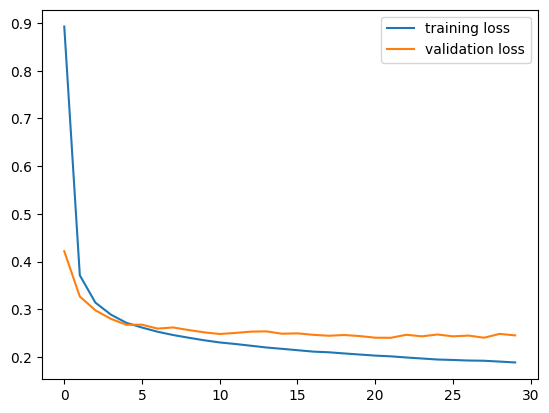

In [17]:
# We have both the training and validation loss curves inside the history object
# Both losses decrease which means that the model is learning correctly and not over/under fitting the data

plt.plot(history.history['loss'], label='training loss');
plt.plot(history.history['val_loss'], label='validation loss');
plt.legend();

Model Performance

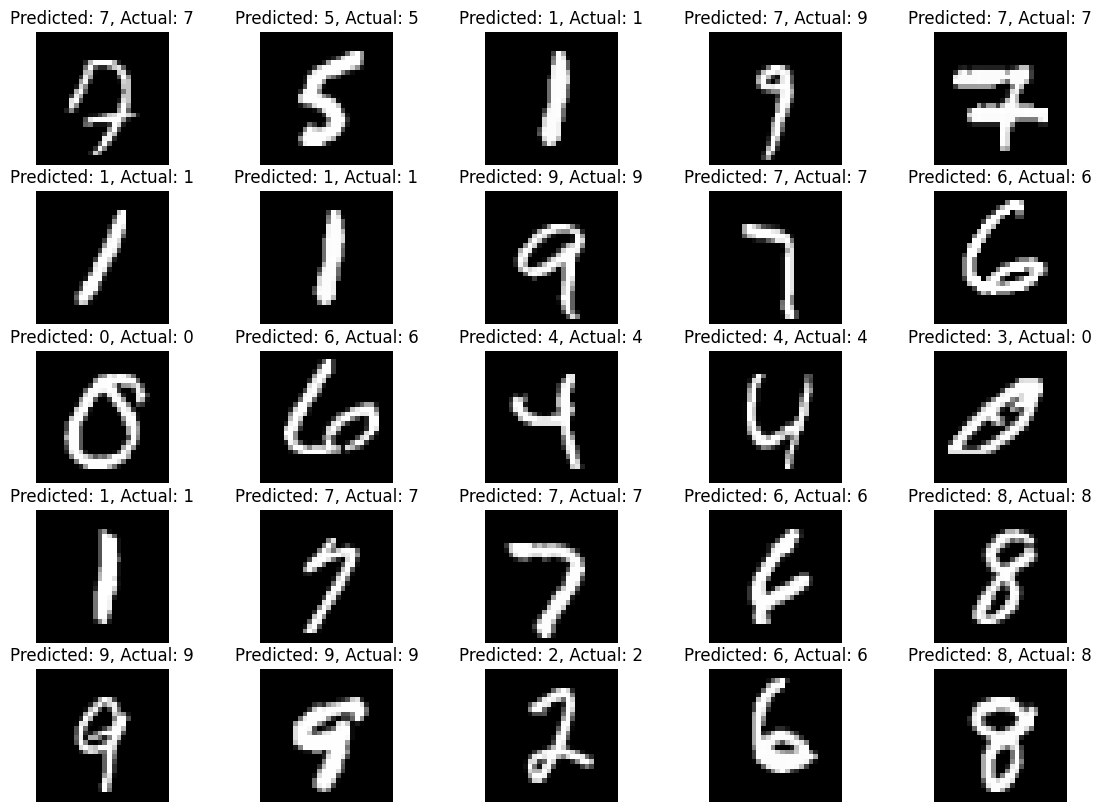

In [24]:
# Similar to the scratch version, let's test how the model performs on testing data

# load the model
model = tf.keras.models.load_model("tf_model.keras")

fig, axes = plt.subplots(5, 5, figsize=(14, 10))

for ax in axes.ravel():

    n = np.random.randint(40000, 42000)

    digit = features[n].reshape(1, 784)
    label = labels[n]

    # forward pass
    probabilities = model(digit, training=False)
    prediction = tf.argmax(probabilities[0]).numpy()

    # display
    digit = features[n].reshape(28, 28)
    ax.imshow(digit, cmap='gray')
    ax.set_title(f"Predicted: {prediction}, Actual: {label}")
    ax.axis('off')